In [1]:
import numpy as np;
import pandas as pd;
import matplotlib.pyplot as plt;
import seaborn as sns;
from sklearn.model_selection import train_test_split;

In [6]:
# Reading the Required dataset
df = pd.read_csv("../datasets/Social_Network_Ads.csv");

In [129]:
# Starting EDA from seeing the sample
df.sample(10);
# df.describe();
# df.info()
# df.isnull().sum();
# df.duplicated().sum();

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
...,...,...,...,...,...
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0


In [131]:
# Extracting Features and Label vlaue from the Dataset
X = df.loc[:,['Age', 'EstimatedSalary']]
y = df["Purchased"];

In [132]:
# Splitting the dataset into training and testing before scaling
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42);

<Axes: ylabel='count'>

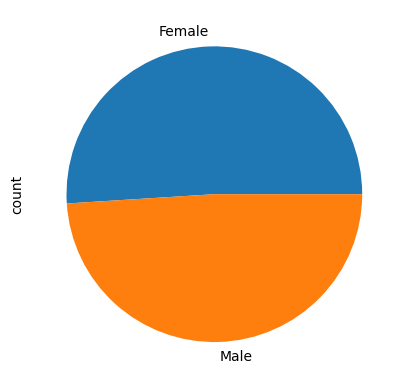

In [133]:
# Performing Univaraite Analysis on the Sex column
df["Gender"].value_counts().plot(kind = 'pie')

In [134]:
# Using Pandas Profiling on the received dataset to see different plots
from ydata_profiling import ProfileReport
profile = ProfileReport(df)
profile

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|███████████████████████████████████████████████████████████████████████████████████| 5/5 [00:00<00:00, 2609.37it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [135]:
# Importing Required dependency from scikit-learn for Standardisation
from sklearn.preprocessing import StandardScaler;

In [136]:
# Creating a Standard Scaler object
scaler = StandardScaler()

# Option1: First Transform and then scale
# scaler.fit(X_train);
# X_train_std = scaler.transform(X_train);

# Option 2: Transform and scale together
X_train_std = scaler.fit_transform(X_train);
X_test_std = scaler_fit.transform(X_test);

In [137]:
# On the transformed numpy array creating back the dataframe
X_train_scaled = pd.DataFrame(X_train_std, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_std, columns=X_test.columns)

In [138]:
# Checking how is the value of mean and std after scaling
np.round(X_train_scaled.describe(), 1)

,Age,EstimatedSalary
count,268.0,268.0
mean,-0.0,0.0
std,1.0,1.0
min,-1.9,-1.6
25%,-0.7,-0.8
50%,-0.1,0.0
75%,0.7,0.5
max,2.2,2.3


<Axes: xlabel='Age', ylabel='EstimatedSalary'>

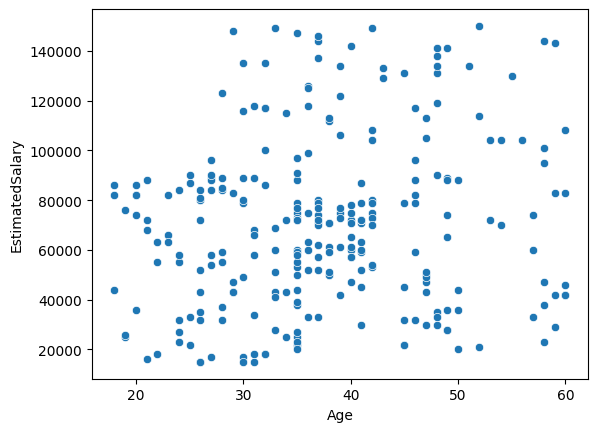

In [150]:
# Individaully plotting the points using Scatter Plt after Scaling
sns.scatterplot(X_train, x = 'Age', y = 'EstimatedSalary')

<Axes: xlabel='Age', ylabel='EstimatedSalary'>

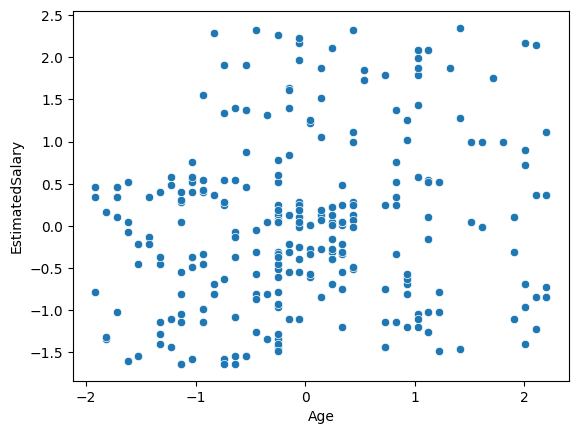

In [140]:
# Individaully plotting the points using Scatter Plt after Scaling
sns.scatterplot(X_train_scaled, x = 'Age', y = 'EstimatedSalary')

<Axes: xlabel='Age', ylabel='EstimatedSalary'>

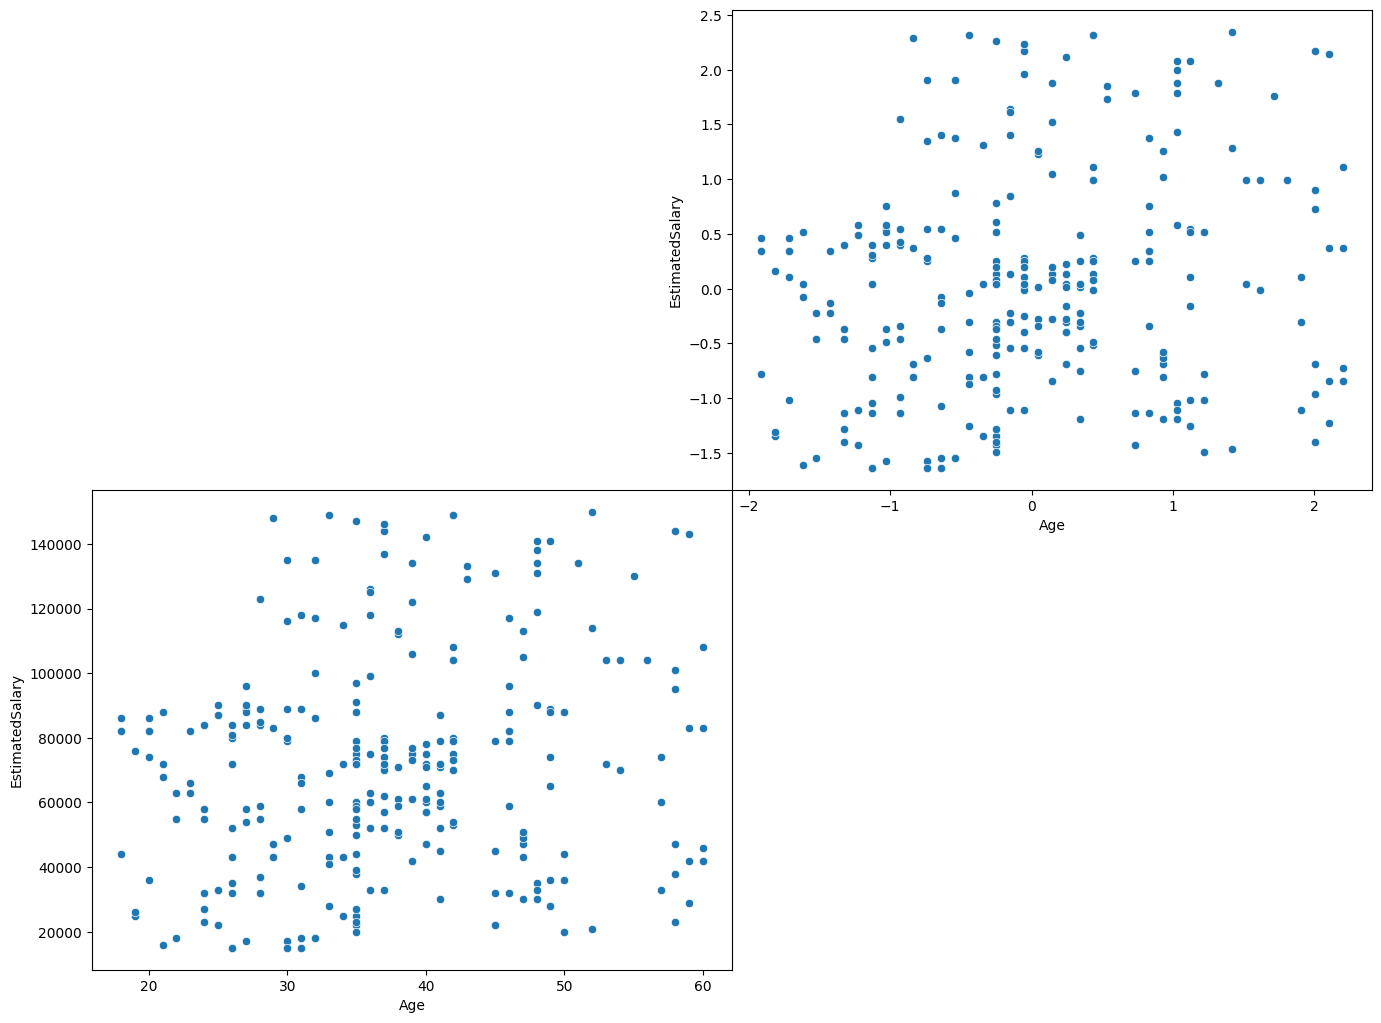

In [155]:
# Plotting both together on the Graph using Matlplotlib
# Creating a figure object
fig = plt.figure();

# Manually adding 1 axes
axes_0 = fig.add_axes([0,0,1,1]);
# Plotting the point before scaling using scatterplot
sns.scatterplot(X_train, x = 'Age', y = 'EstimatedSalary', ax=axes_0)

# Manually adding another axes
axes_1 = fig.add_axes([1,1,1,1]);
# Plotting the point afer scaling using scatterplot
sns.scatterplot(X_train_scaled, x = 'Age', y = 'EstimatedSalary',ax=axes_1)

<Axes: xlabel='Age', ylabel='EstimatedSalary'>

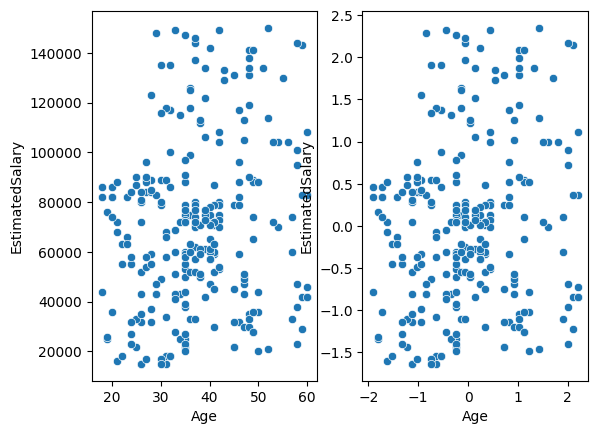

In [153]:
# Option 2: In case we don't want to create axes manually directly making use of plt.subplots()
fig, axes = plt.subplots(nrows=1, ncols=2);
# Plotting the point before scaling using scatterplot
sns.scatterplot(X_train, x = 'Age', y = 'EstimatedSalary', ax=axes[0])
# Plotting the point afer scaling using scatterplot
sns.scatterplot(X_train_scaled, x = 'Age', y = 'EstimatedSalary',ax=axes[1])